In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
covered_emissions = pd.read_csv('output-data/timeseries_covered_emissions.csv')
emission_fluxes = pd.read_csv('output-data/timeseries_emission_fluxes.csv')
project_fluxes = pd.read_csv('output-data/timeseries_project_fluxes.csv')

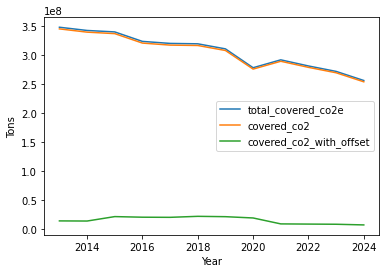

In [25]:
# Most "covered emisssions" are co2; a small portion of those emissions are compensated for using offsets

plot = covered_emissions.plot(x='report_year', y=['total_covered_co2e', 'covered_co2'])
emission_fluxes.plot(x='year', y='co2_flux', ax=plot, label='covered_co2_with_offset')
plt.xlabel('Year')
plt.ylabel('Tons')
plt.show()

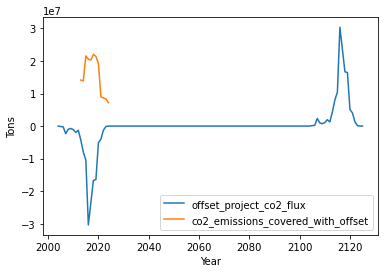

Offset project CO2 flux: -128,982,213
Emissions covered with offset: 186,063,886


In [35]:
plot = project_fluxes.plot(x='year', y='co2_flux', label='offset_project_co2_flux')
emission_fluxes.plot(x='year', y='co2_flux', ax=plot, label='co2_emissions_covered_with_offset')
plt.xlabel('Year')
plt.ylabel('Tons')
plt.show()

project_total = project_fluxes[(project_fluxes['year'] >= 2005) & (project_fluxes['year'] <= 2024)]['co2_flux'].sum()
emission_total = emission_fluxes[(emission_fluxes['year'] >= 2005) & (emission_fluxes['year'] <= 2024)]['co2_flux'].sum()
print(f"Offset project CO2 flux: {project_total:,.0f}")
print(f"Emissions covered with offset: {emission_total:,.0f}")

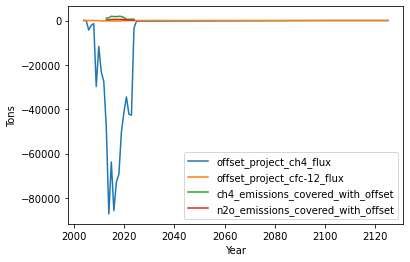

Offset project CO2 flux: -128,982,213
Emissions covered with offset: 186,063,886


In [38]:
plot = project_fluxes.plot(x='year', y='ch4_flux', label='offset_project_ch4_flux')
project_fluxes.plot(x='year', y='cfc-12_flux', label='offset_project_cfc-12_flux', ax=plot)
emission_fluxes.plot(x='year', y='ch4_flux', label='ch4_emissions_covered_with_offset', ax=plot)
emission_fluxes.plot(x='year', y='n2o_flux', label='n2o_emissions_covered_with_offset', ax=plot)
plt.xlabel('Year')
plt.ylabel('Tons')
plt.show()

project_total = project_fluxes[(project_fluxes['year'] >= 2005) & (project_fluxes['year'] <= 2024)]['co2_flux'].sum()
emission_total = emission_fluxes[(emission_fluxes['year'] >= 2005) & (emission_fluxes['year'] <= 2024)]['co2_flux'].sum()
print(f"Offset project CO2 flux: {project_total:,.0f}")
print(f"Emissions covered with offset: {emission_total:,.0f}")

In [42]:
# protocols w/ gwp conversions point to defer to MRR section 95102(a) for specific gwp values. i think that 
# means they should follow the same 2021 switch seen in the MRR data. 

gwp_values_2021_onwards = {
    'co2': 1, 
    'ch4': 25,
    'n2o': 298
}

gwp_values_2020_prior = {
    'co2': 1, 
    'ch4': 21,
    'n2o': 310
}

cfc_12_gwp = 10900 # 2014 ODS protocol (Table B.1); 2011 ODS protocol (Table 5.1)


# filter to time period
project_slice = project_fluxes[(project_fluxes['year'] >= 2005) & (project_fluxes['year'] <= 2024)].copy()
emission_slice = emission_fluxes[(emission_fluxes['year'] >= 2005) & (emission_fluxes['year'] <= 2024)].copy()

# add year-specific gwps
for df_slice in [project_slice, emission_slice]:
    df_slice['gwp_ch4'] = df_slice['year'].apply(lambda y: gwp_values_2020_prior['ch4'] if y <= 2020 else gwp_values_2021_onwards['ch4'])
emission_slice['gwp_n2o'] = emission_slice['year'].apply(lambda y: gwp_values_2020_prior['n2o'] if y <= 2020 else gwp_values_2021_onwards['n2o'])

# projects
co2_total = project_slice['co2_flux'].sum()
ch4_total = (project_slice['ch4_flux'] * project_slice['gwp_ch4']).sum()
cfc_total = (project_slice['cfc-12_flux'] * cfc_12_gwp).sum()
project_total_co2e = co2_total + ch4_total + cfc_total
print(f"Offset projects:")
print(f"  CO2:   {co2_total:,.0f}")
print(f"  CH4:   {ch4_total:,.0f} CO2e")
print(f"  CFC-12:{cfc_total:,.0f} CO2e")
print(f"  Total: {project_total_co2e:,.0f} CO2e")
print()

# emissions
co2_total = emission_slice['co2_flux'].sum()
ch4_total = (emission_slice['ch4_flux'] * emission_slice['gwp_ch4']).sum()
n2o_total = (emission_slice['n2o_flux'] * emission_slice['gwp_n2o']).sum()
emission_total_co2e = co2_total + ch4_total + n2o_total
print(f"Emissions covered with offset:")
print(f"  CO2:   {co2_total:,.0f}")
print(f"  CH4:   {ch4_total:,.0f} CO2e")
print(f"  N2O:   {n2o_total:,.0f} CO2e")
print(f"  Total: {emission_total_co2e:,.0f} CO2e")

Offset projects:
  CO2:   -128,982,213
  CH4:   -16,054,514 CO2e
  CFC-12:-22,210,086 CO2e
  Total: -167,246,813 CO2e

Emissions covered with offset:
  CO2:   186,063,886
  CH4:   327,256 CO2e
  N2O:   1,316,723 CO2e
  Total: 187,707,865 CO2e


Theortically, the total numbers above should match! We're either overestimating the proportion of covered emissions that are associated with offset use, or underestimating the project fluxes. 

Thing to go back and check: 
- How much of a difference would including the full suite / diversity of ODS distruction fluxes make? 